In [36]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [37]:
# Import the data

df = pd.read_csv('data/clustered_data.csv')
df.head()

,Unnamed: 0,age,job,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,was_previously_contacted,positive_campaign_result,cluster
0,0,56,housemaid,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,0,0,2
1,1,57,services,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0,2
2,2,37,services,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,0,0,2
3,3,40,admin.,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,0,0,2
4,4,56,services,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,0,0,2


In [38]:
df.groupby('cluster')['cluster'].count()

cluster
0     5433
1     8320
2    26050
Name: cluster, dtype: int64

In [39]:
df.isna().sum()

Unnamed: 0                   0
age                          0
job                          0
campaign                     0
term_deposit_subscribed      0
has_housing_loan             0
has_personal_loan            0
default_status               0
consumer_confidence_index    0
euribor_3mo_rate             0
marital_status               0
education_level              0
previous_contacted           0
communication_type           0
last_contact_month           0
last_contact_duration_sec    0
was_previously_contacted     0
positive_campaign_result     0
cluster                      0
dtype: int64

In [40]:
# Drop Unnamed:0 index column

df = df.drop(columns=['Unnamed: 0', 'last_contact_duration_sec'])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        39803 non-null  int64  
 1   job                        39803 non-null  object 
 2   campaign                   39803 non-null  int64  
 3   term_deposit_subscribed    39803 non-null  int64  
 4   has_housing_loan           39803 non-null  object 
 5   has_personal_loan          39803 non-null  object 
 6   default_status             39803 non-null  object 
 7   consumer_confidence_index  39803 non-null  float64
 8   euribor_3mo_rate           39803 non-null  float64
 9   marital_status             39803 non-null  object 
 10  education_level            39803 non-null  object 
 11  previous_contacted         39803 non-null  int64  
 12  communication_type         39803 non-null  object 
 13  last_contact_month         39803 non-null  obj

# Preprocessing

In [42]:
# Define the target column
target_col = 'term_deposit_subscribed'   # Make it a string (not a list)

# Get all numeric columns and remove the target if it's numeric
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Remove target from numeric_cols (in case it's detected as numeric)
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Get all categorical (object) columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target from categorical_cols (in case it's stored as object/string)
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# Optional: Print to verify
print("Target column:", target_col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Total features:", len(numeric_cols) + len(categorical_cols))

Target column: term_deposit_subscribed
Numeric columns: ['age', 'campaign', 'consumer_confidence_index', 'euribor_3mo_rate', 'previous_contacted', 'was_previously_contacted', 'positive_campaign_result', 'cluster']
Categorical columns: ['job', 'has_housing_loan', 'has_personal_loan', 'default_status', 'marital_status', 'education_level', 'communication_type', 'last_contact_month']
Total features: 16


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Define X and y
target_col = 'term_deposit_subscribed'

X = df[numeric_cols + categorical_cols].copy()
y = df[target_col].copy()

# Convert target to 0/1 if it's still 'yes'/'no'
if y.dtype == 'object':
    y = y.map({'yes': 1, 'no': 0})

# 2. Split the data (stratified - very important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Class distribution - Train: {y_train.value_counts(normalize=True)}")

# 3. Define Preprocessing (this stays the same)
numeric_transformer = make_pipeline(StandardScaler())
categorical_transformer = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 4. Create Full Modeling Pipelines

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',      # Helps with imbalance
        random_state=42,
        n_jobs=-1
    ))
])

# SVM Pipeline
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,             # Important for AUC and PR curves
        class_weight='balanced',
        random_state=42,
        max_iter=-1                 # prevent very long training
    ))
])

Train shape: (31842, 16) | Test shape: (7961, 16)
Class distribution - Train: term_deposit_subscribed
0    0.887256
1    0.112744
Name: proportion, dtype: float64


In [46]:
# Train the models
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Training SVM...")
svm_pipeline.fit(X_train, y_train)

# Make predictions
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

svm_pred = svm_pipeline.predict(X_test)
svm_proba = svm_pipeline.predict_proba(X_test)[:, 1]

Training Random Forest...
Training SVM...


Evaluating Random Forest...

          Random Forest Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9625    0.9768    0.9696      7064
           1     0.7929    0.7001    0.7436       897

    accuracy                         0.9456      7961
   macro avg     0.8777    0.8384    0.8566      7961
weighted avg     0.9434    0.9456    0.9441      7961

Accuracy          : 0.9456
ROC-AUC           : 0.9654
PR-AUC (Average Precision): 0.8310
F1 Score (macro)  : 0.8566
F1 Score (minority class '1'): 0.7436


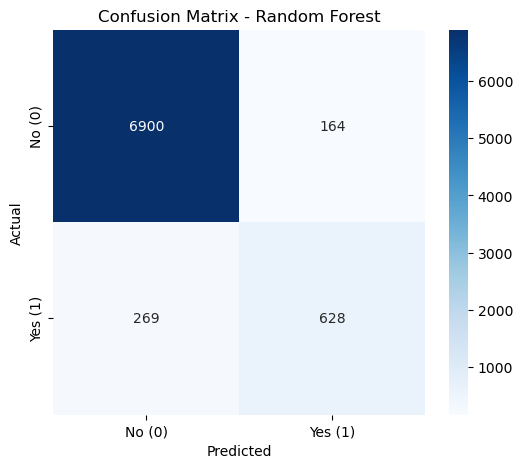

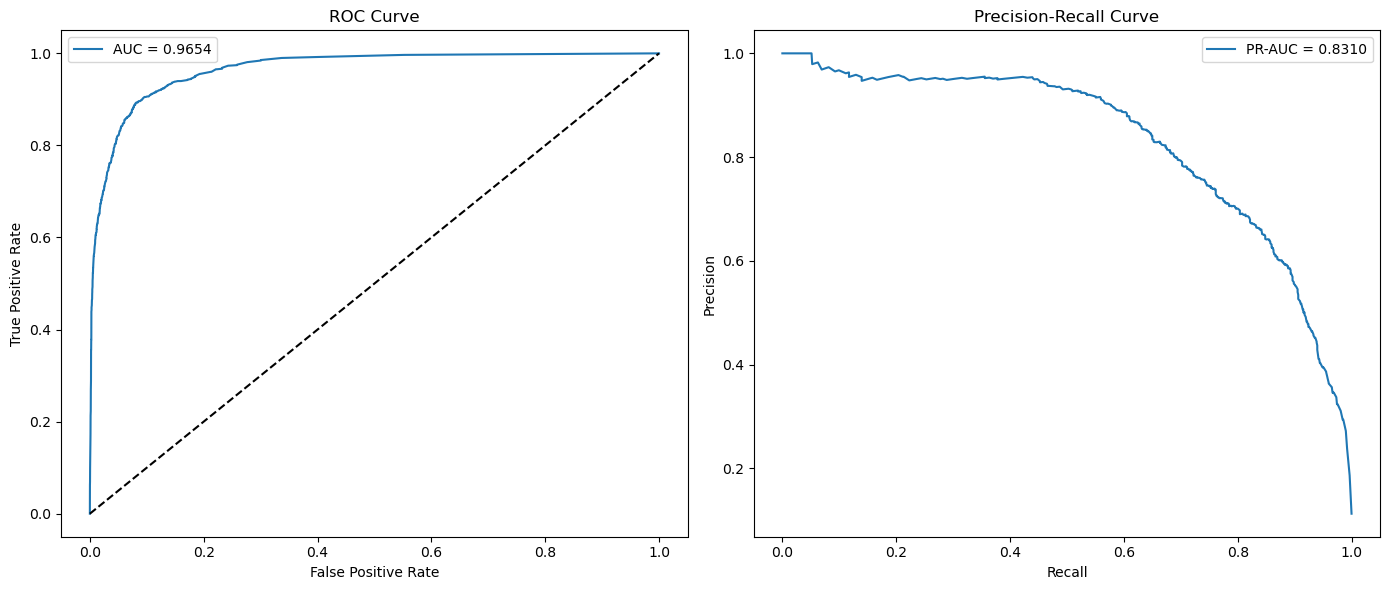


Evaluating SVM...

          SVM Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9855    0.9066    0.9444      7064
           1     0.5489    0.8952    0.6805       897

    accuracy                         0.9053      7961
   macro avg     0.7672    0.9009    0.8125      7961
weighted avg     0.9363    0.9053    0.9147      7961

Accuracy          : 0.9053
ROC-AUC           : 0.9610
PR-AUC (Average Precision): 0.7288
F1 Score (macro)  : 0.8125
F1 Score (minority class '1'): 0.6805


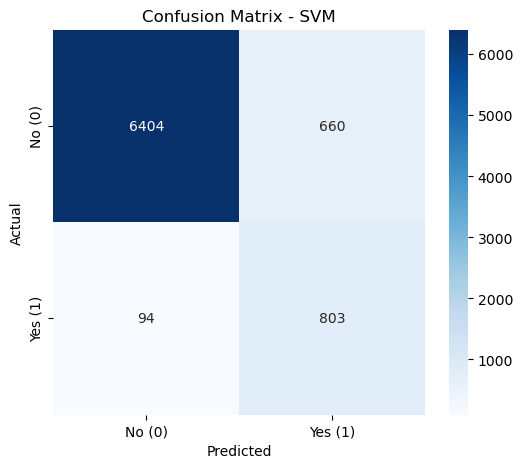

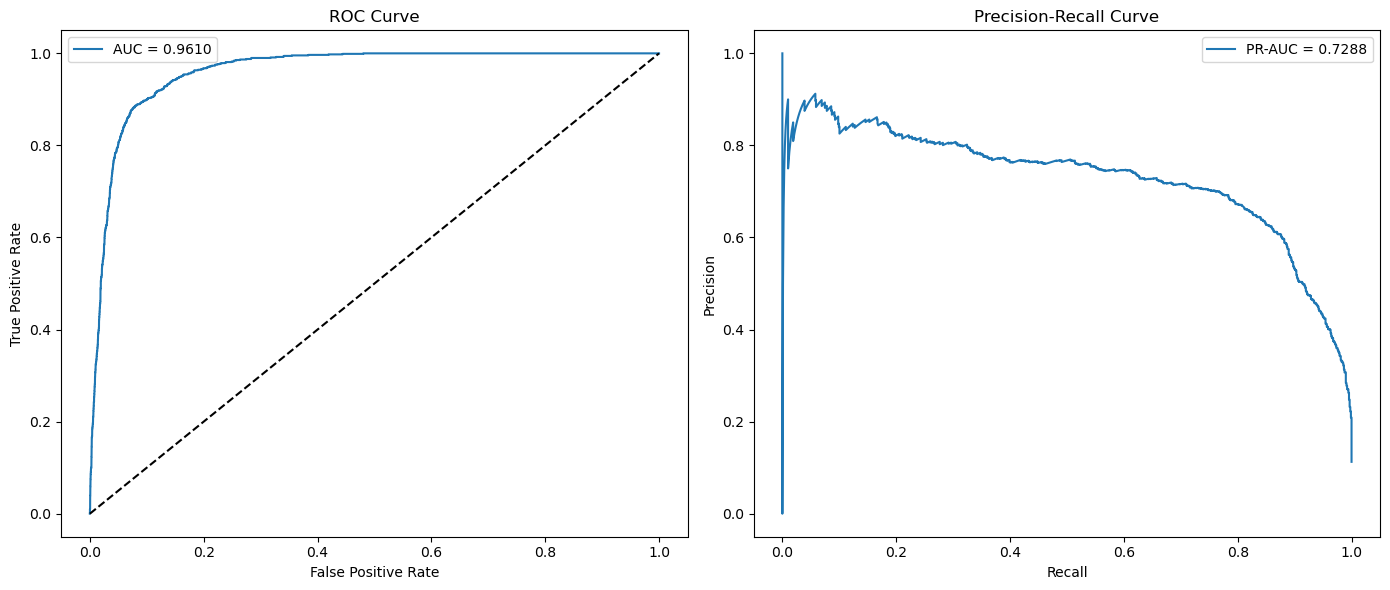

In [47]:
import pandas as pd
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score, 
    average_precision_score,   # PR-AUC
    f1_score, 
    precision_score, 
    recall_score,
    roc_curve, 
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Function to evaluate a model
def evaluate_model(model, X_test, y_test, model_name="Model"):
    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    print(f"\n{'='*60}")
    print(f"          {model_name} Evaluation")
    print(f"{'='*60}")
    
    # 1. Classification Report (includes Precision, Recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # 2. Key Metrics
    print(f"Accuracy          : { (y_pred == y_test).mean():.4f}")
    print(f"ROC-AUC           : {roc_auc_score(y_test, y_proba):.4f}" if y_proba is not None else "ROC-AUC: N/A (no probabilities)")
    print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_proba):.4f}" if y_proba is not None else "PR-AUC: N/A")
    print(f"F1 Score (macro)  : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"F1 Score (minority class '1'): {f1_score(y_test, y_pred, pos_label=1):.4f}")
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No (0)', 'Yes (1)'], 
                yticklabels=['No (0)', 'Yes (1)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # 4. Optional: ROC and PR Curves (side by side)
    if y_proba is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
        axes[0].plot([0,1], [0,1], 'k--')
        axes[0].set_title('ROC Curve')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].legend()
        
        # Precision-Recall Curve
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        axes[1].plot(rec, prec, label=f'PR-AUC = {average_precision_score(y_test, y_proba):.4f}')
        axes[1].set_title('Precision-Recall Curve')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend()
        plt.tight_layout()
        plt.show()

# ====================== Run Evaluation ======================

print("Evaluating Random Forest...")
evaluate_model(rf_pipeline, X_test, y_test, model_name="Random Forest")

print("\nEvaluating SVM...")
evaluate_model(svm_pipeline, X_test, y_test, model_name="SVM")

In [48]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid focused on improving precision / PR-AUC
rf_param_grid = {
    'classifier__n_estimators': [300, 400, 500, 600],
    'classifier__max_depth': [None, 20, 25, 30],
    'classifier__min_samples_split': [2, 5, 8, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=40,                    # You can reduce to 25 if it's too slow
    scoring='average_precision',  # PR-AUC — aligns with your high-precision goal
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest tuning (focused on PR-AUC / Precision)...")
rf_random_search.fit(X_train, y_train)

# Show best results
print("\nBest parameters:")
print(rf_random_search.best_params_)
print(f"Best CV PR-AUC: {rf_random_search.best_score_:.4f}")

best_rf_pipeline = rf_random_search.best_estimator_

Starting Random Forest tuning (focused on PR-AUC / Precision)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters:
{'classifier__n_estimators': 600, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 25, 'classifier__class_weight': 'balanced_subsample'}
Best CV PR-AUC: 0.8277



=== Tuned Random Forest Evaluation ===

          Tuned Random Forest Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9637    0.9747    0.9692      7064
           1     0.7809    0.7113    0.7445       897

    accuracy                         0.9450      7961
   macro avg     0.8723    0.8430    0.8568      7961
weighted avg     0.9431    0.9450    0.9439      7961

Accuracy          : 0.9450
ROC-AUC           : 0.9702
PR-AUC (Average Precision): 0.8362
F1 Score (macro)  : 0.8568
F1 Score (minority class '1'): 0.7445


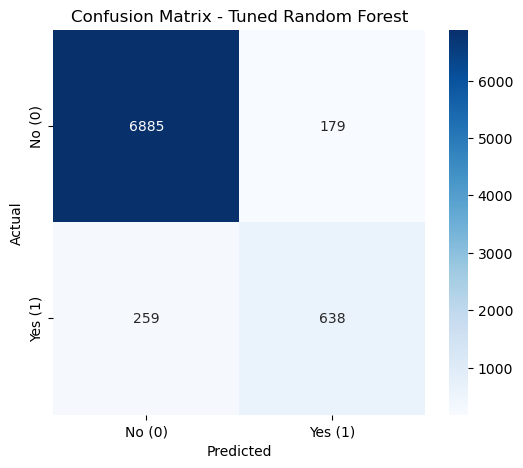

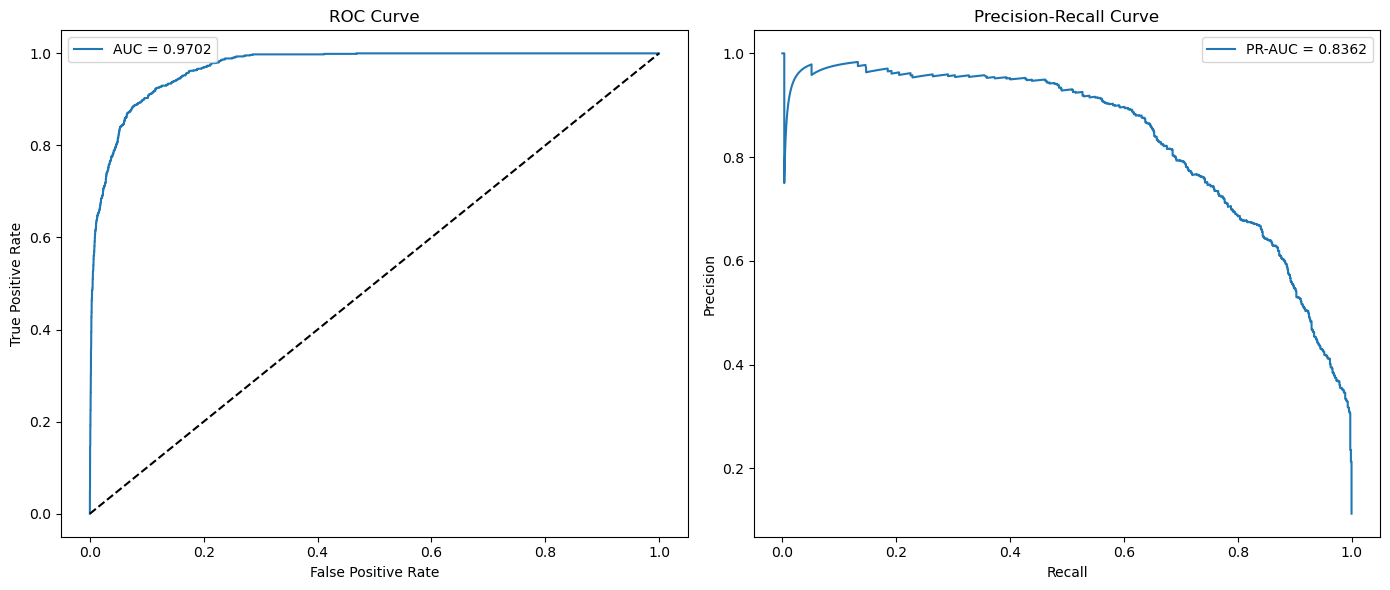

In [49]:
# RF Eval after hyper param tuning, model ios slightly better

print("\n=== Tuned Random Forest Evaluation ===")
evaluate_model(best_rf_pipeline, X_test, y_test, model_name="Tuned Random Forest")

Training Base XGBoost model...

=== Base XGBoost Evaluation ===

          Base XGBoost Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9811    0.9335    0.9567      7064
           1     0.6210    0.8584    0.7206       897

    accuracy                         0.9250      7961
   macro avg     0.8010    0.8959    0.8387      7961
weighted avg     0.9405    0.9250    0.9301      7961

Accuracy          : 0.9250
ROC-AUC           : 0.9714
PR-AUC (Average Precision): 0.8539
F1 Score (macro)  : 0.8387
F1 Score (minority class '1'): 0.7206


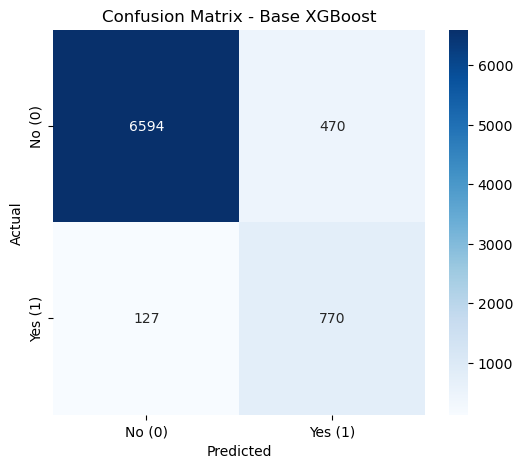

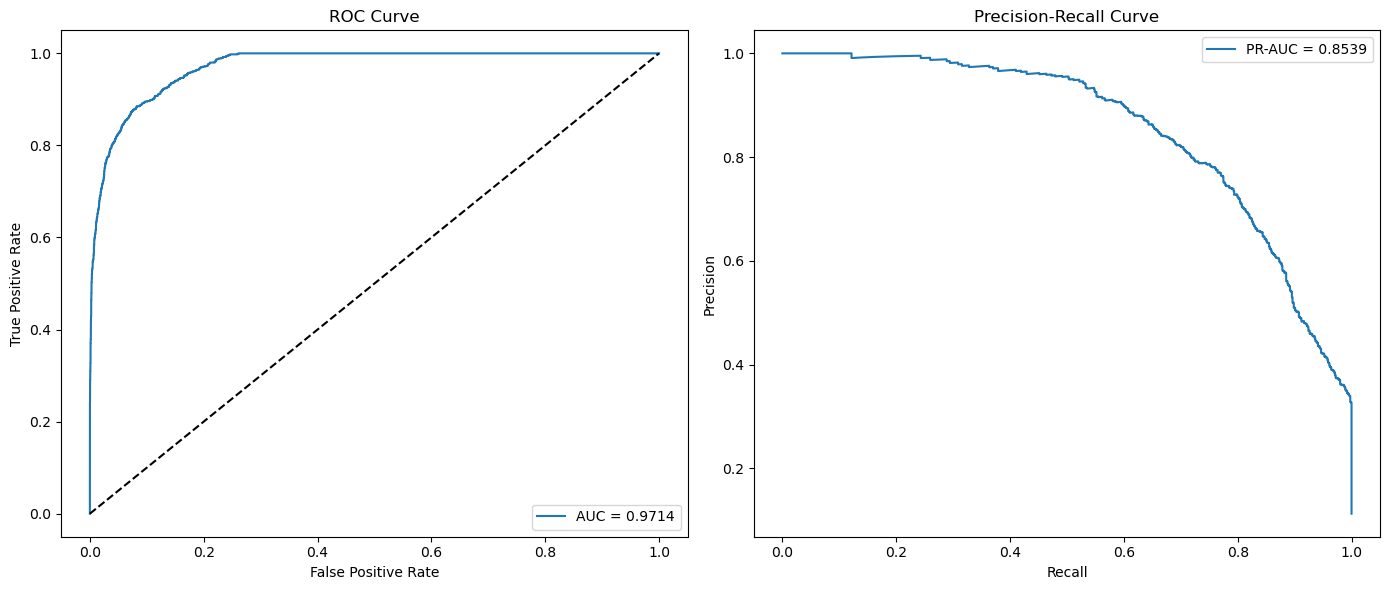

In [50]:
from xgboost import XGBClassifier

# XGBoost Pipeline - Base version with imbalance handling
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr',                    # Good for your PR focus
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])   # Handles imbalance
    ))
])

print("Training Base XGBoost model...")
xgb_pipeline.fit(X_train, y_train)

print("\n=== Base XGBoost Evaluation ===")
evaluate_model(xgb_pipeline, X_test, y_test, model_name="Base XGBoost")

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define a new pipeline for tuning (or reuse and tune the classifier params)
xgb_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr'
    ))
])

# Parameter grid (focused on improving precision / PR performance)
xgb_param_grid = {
    'classifier__n_estimators': [300, 400, 500, 600],
    'classifier__max_depth': [4, 5, 6, 7, 8],
    'classifier__learning_rate': [0.05, 0.08, 0.1, 0.15],
    'classifier__subsample': [0.7, 0.8, 0.85, 0.9],
    'classifier__colsample_bytree': [0.7, 0.8, 0.85],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__gamma': [0, 0.1, 0.2],
    'classifier__scale_pos_weight': [1, len(y_train[y_train==0]) / len(y_train[y_train==1])]  # try both
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=40,                    # Adjust based on time (20-50 is reasonable)
    scoring='average_precision',  # PR-AUC — aligns with your goal
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost hyperparameter tuning...")
xgb_random_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(xgb_random_search.best_params_)
print(f"Best CV PR-AUC: {xgb_random_search.best_score_:.4f}")

best_xgb_pipeline = xgb_random_search.best_estimator_

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found:
{'classifier__subsample': 0.85, 'classifier__scale_pos_weight': 1, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 3, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.7}
Best CV PR-AUC: 0.8522



=== Tuned XGBoost Evaluation ===

          Tuned XGBoost Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.9656    0.9775    0.9715      7064
           1     0.8037    0.7258    0.7627       897

    accuracy                         0.9491      7961
   macro avg     0.8847    0.8516    0.8671      7961
weighted avg     0.9474    0.9491    0.9480      7961

Accuracy          : 0.9491
ROC-AUC           : 0.9751
PR-AUC (Average Precision): 0.8648
F1 Score (macro)  : 0.8671
F1 Score (minority class '1'): 0.7627


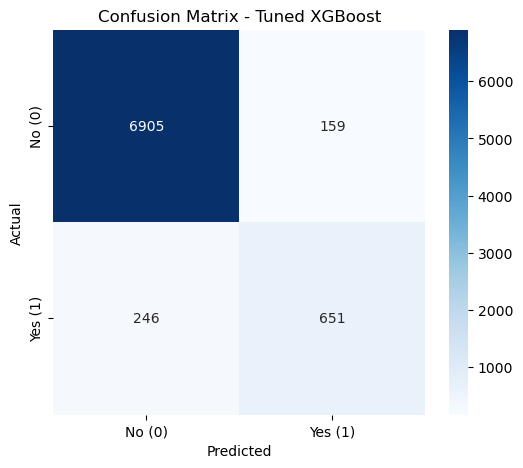

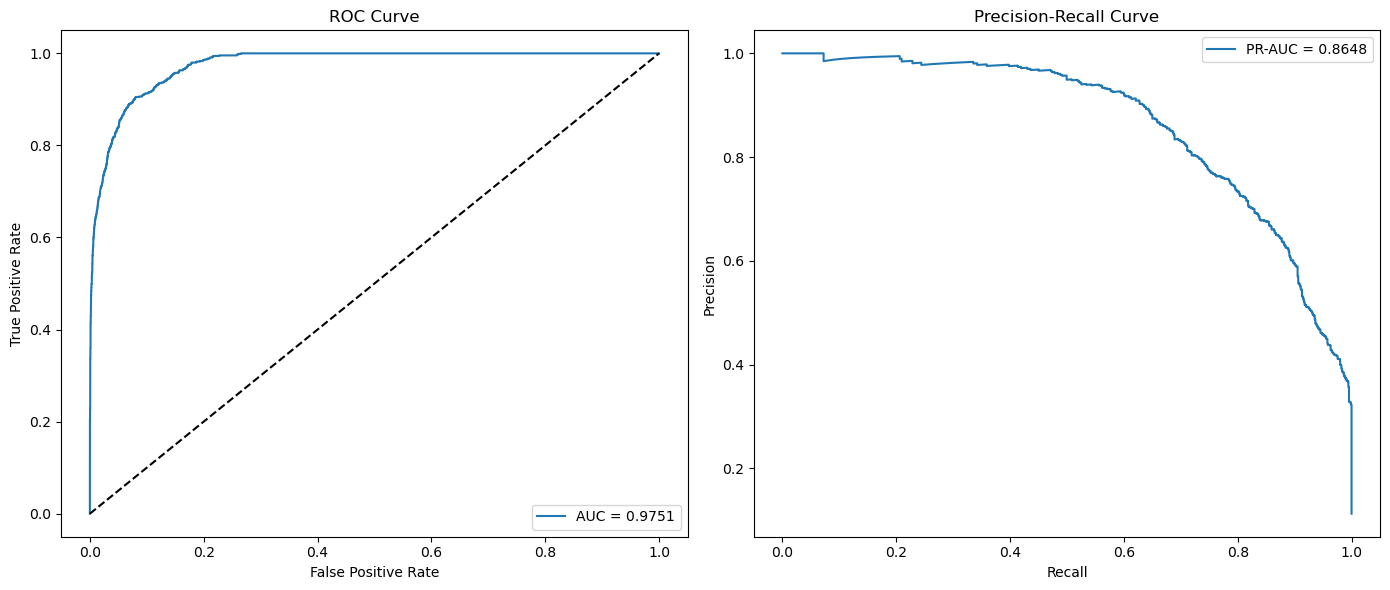

In [52]:
print("\n=== Tuned XGBoost Evaluation ===")
evaluate_model(best_xgb_pipeline, X_test, y_test, model_name="Tuned XGBoost")

In [55]:
import joblib
# 1. Save the full model pipeline (still recommended to keep together)
# Saving the tuned XGB Model

joblib.dump(best_xgb_pipeline, 'tuned_xgboost_model.pkl')

['tuned_xgboost_model.pkl']

In [57]:
# All columns used for modeling (XBG Classification)

df.columns

Index(['age', 'job', 'campaign', 'term_deposit_subscribed', 'has_housing_loan',
       'has_personal_loan', 'default_status', 'consumer_confidence_index',
       'euribor_3mo_rate', 'marital_status', 'education_level',
       'previous_contacted', 'communication_type', 'last_contact_month',
       'was_previously_contacted', 'positive_campaign_result', 'cluster'],
      dtype='object')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        39803 non-null  int64  
 1   job                        39803 non-null  object 
 2   campaign                   39803 non-null  int64  
 3   term_deposit_subscribed    39803 non-null  int64  
 4   has_housing_loan           39803 non-null  object 
 5   has_personal_loan          39803 non-null  object 
 6   default_status             39803 non-null  object 
 7   consumer_confidence_index  39803 non-null  float64
 8   euribor_3mo_rate           39803 non-null  float64
 9   marital_status             39803 non-null  object 
 10  education_level            39803 non-null  object 
 11  previous_contacted         39803 non-null  int64  
 12  communication_type         39803 non-null  object 
 13  last_contact_month         39803 non-null  obj

In [77]:
df['positive_campaign_result'].unique()

array([0, 1], dtype=int64)